# W2 D28 — Open Practice: Patient Readmission
**Topics:** Synthetic MedPulse patient data | Readmission prediction, cost matrix, pipeline

**Q1** EDA — readmission rate by condition & age group
**Q2** Full preprocessing pipeline
**Q3** Model comparison (LR, RF, GBM)
**Q4** Cost-sensitive threshold (readmission has asymmetric cost)
**Q5** Business case: ROI of early intervention


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')

Libraries loaded


In [2]:
# Synthetic MedPulse patient readmission dataset
n = 4000
np.random.seed(420)
age_grp = np.random.choice(['18-40','41-60','61-75','75+'], n, p=[0.25, 0.30, 0.30, 0.15])
condition = np.random.choice(['diabetes','cardiac','respiratory','orthopedic','other'], n, p=[0.25,0.20,0.20,0.20,0.15])
los = np.random.randint(1, 15, n)  # length of stay
n_prior = np.random.poisson(1.2, n)  # prior admissions
has_followup = np.random.choice([0,1], n, p=[0.4, 0.6])
insurance = np.random.choice(['private','public','uninsured'], n, p=[0.50, 0.40, 0.10])
# DGP
age_num = {'18-40':1,'41-60':2,'61-75':3,'75+':4}
age_v = np.array([age_num[a] for a in age_grp])
cond_risk = {'diabetes':1.0,'cardiac':1.2,'respiratory':0.8,'orthopedic':0.2,'other':0.0}
cond_v = np.array([cond_risk[c] for c in condition])
logit = -3 + 0.5*age_v + cond_v + 0.1*los + 0.3*n_prior - 0.8*has_followup + 0.4*(insurance=='uninsured').astype(int)
prob = 1/(1+np.exp(-logit))
readmitted = (np.random.rand(n) < prob).astype(int)
df = pd.DataFrame({'age_group':age_grp,'condition':condition,'length_of_stay':los,
                   'prior_admissions':n_prior,'has_followup':has_followup,
                   'insurance':insurance,'readmitted':readmitted})
print(f'Dataset: {df.shape}  Readmission rate: {readmitted.mean():.1%}')

Dataset: (4000, 7)  Readmission rate: 41.9%


In [3]:
display(df.head())

,age_group,condition,length_of_stay,prior_admissions,has_followup,insurance,readmitted
0,41-60,orthopedic,11,0,0,public,0
1,41-60,cardiac,6,1,0,uninsured,0
2,41-60,cardiac,9,0,0,private,0
3,18-40,diabetes,2,1,0,private,1
4,75+,diabetes,5,2,1,public,1


## Q1 — EDA: Readmission by Condition & Age Group

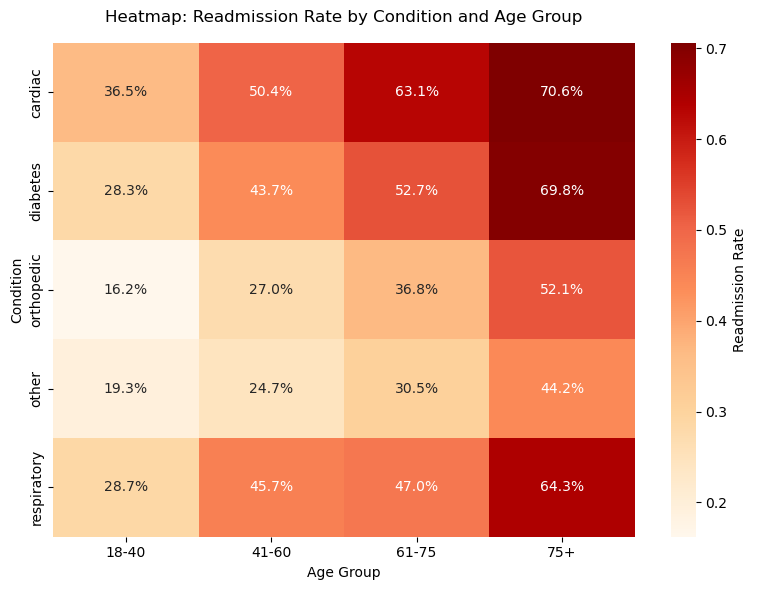

In [11]:
# 1. Pivot the data to get average readmission rates
# Rows = Condition, Columns = Age, Values = Mean Readmission
heatmap_data = df.pivot_table(
    values='readmitted', 
    index='condition', 
    columns='age_group', 
    aggfunc='mean'
)

# Reindex to force chronological left-to-right age progression
age_order = ['18-40', '41-60', '61-75', '75+']
heatmap_data = heatmap_data.reindex(columns=age_order)

# 2. Set up the plotting environment
plt.figure(figsize=(8, 6))

# 3. Create the heatmap
# annot=True prints values; fmt='.1%' formats decimals as percentages
# cmap='OrRd' creates a light-orange to dark-red warning palette
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='.1%', 
    cmap='OrRd', 
    cbar_kws={'label': 'Readmission Rate'}
)

# 4. Final polish
plt.title('Heatmap: Readmission Rate by Condition and Age Group', pad=15)
plt.ylabel('Condition')
plt.xlabel('Age Group')

plt.tight_layout()
plt.show()

*** Takeaways from the plot:

1/ Age is a dominant risk driver: Readmission rates consistently climb across all medical conditions as patients transition from younger cohorts to the 75+ demographic.

2/ Cardiac patients face the highest risk: This category registers the most critical readmission frequencies, peaking heavily at 70.6% for the oldest age bracket.

3/ Orthopedic cases show the lowest baseline: Younger orthopedic patients (18–40) maintain the lowest overall readmission incidence at 16.2%.

## Q2 — Full Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer

# 1. Features and log-transformed target
X = df.drop(columns=['readmitted'], errors='ignore')
y = df['readmitted']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=420, stratify=y
)

# 3. Preprocessor
numeric_features    = ['length_of_stay', 'prior_admissions']
categorical_features = ['age_group', 'condition', 'insurance']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)


## Q3 — Model Comparison (LR, RF, GBM)

In [35]:
# 1. Detect post-preprocessor binary/categorical column indices dynamically
_X_temp = preprocessor.fit_transform(X_train, y_train)
n_total_cols = _X_temp.shape[1]

# has_followup lands last via remainder='passthrough'
# OHE columns for age_group, condition, insurance land after numeric
# All OHE outputs are already 0/1 — pass them ALL as categorical to SMOTENC
n_numeric = len(numeric_features)  # 2 scaled numeric cols
cat_indices_post = list(range(n_numeric, n_total_cols))  # everything after numeric

print(f"Post-preprocessor shape: {_X_temp.shape}")
print(f"Numeric cols (0 to {n_numeric-1}): scaled, SMOTE interpolates freely")
print(f"Categorical indices ({n_numeric} to {n_total_cols-1}): OHE + passthrough binary")

# 2. Rebuild preprocessor fresh for clean pipeline state
preprocessor_fresh = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

models = {
    'Logistic Regression': ImbPipeline([
        ('preprocessor', preprocessor_fresh),
        ('smotenc', SMOTENC(categorical_features=cat_indices_post, random_state=420)),
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ]),
    'Random Forest': ImbPipeline([
        ('preprocessor', preprocessor_fresh),
        ('smotenc', SMOTENC(categorical_features=cat_indices_post, random_state=420)),
        ('model', RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1))
    ]),
    'GBM': ImbPipeline([
        ('preprocessor', preprocessor_fresh),
        ('smotenc', SMOTENC(categorical_features=cat_indices_post, random_state=420)),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=420))
    ]),
}

# 3. Configure Stratified 5-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 4. Define the evaluation metrics
scoring_metrics = {
    'ROC-AUC': 'roc_auc',
    'PR-AUC': 'average_precision',
    'Recall': 'recall',      # <-- Added to track sensitivity/catch rate
    'F1': 'f1',
    'Accuracy': 'accuracy'
}

# 5. Loop through models and execute cross_validate
results_data = []

for name, pipeline in models.items():
    # cross_validate allows evaluating multiple metrics simultaneously
    scores = cross_validate(
        pipeline, X_train, y_train, 
        cv=cv_strategy, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Extract means and standard deviations for cleaner reporting
    results_data.append({
        'Model': name,
        'ROC-AUC (Mean)': np.mean(scores['test_ROC-AUC']).round(4),
        'PR-AUC (Mean)': np.mean(scores['test_PR-AUC']).round(4),
        'Recall (Mean)': np.mean(scores['test_Recall']).round(4),
        'F1 (Mean)': np.mean(scores['test_F1']).round(4),
        'Accuracy (Mean)': np.mean(scores['test_Accuracy']).round(4)
    })
# 6. Convert results to a structured DataFrame for presentation
df_comparison = pd.DataFrame(results_data)
display(df_comparison.sort_values(by='Recall (Mean)', ascending=False))

Post-preprocessor shape: (3200, 12)
Numeric cols (0 to 1): scaled, SMOTE interpolates freely
Categorical indices (2 to 11): OHE + passthrough binary


,Model,ROC-AUC (Mean),PR-AUC (Mean),Recall (Mean),F1 (Mean),Accuracy (Mean)
0,Logistic Regression,0.7319,0.6592,0.6272,0.6178,0.6753
2,GBM,0.7143,0.6375,0.6257,0.6096,0.6641
1,Random Forest,0.6331,0.5346,0.5257,0.5250,0.6012


1/ Logistic Regression wins entirely: It achieves the highest scores across all five performance indicators, outperforming both tree models.

2/ Highest patient catch rate: Logistic Regression delivers the top operational Recall at 62.72%, successfully flagging the most high-risk cases.

3/ Random Forest underperforms: Lower recall and accuracy suggest the ensemble's high variance hurts more than it helps on this relatively clean logistic DGP given LR's simpler decision boundary is a better fit.

## Q4 — Cost-Sensitive Threshold Tuning

Optimal Threshold:                        0.10
Minimum Operational Cost:                 $628,800.00
Savings vs default threshold (t=0.50):    $397,200.00


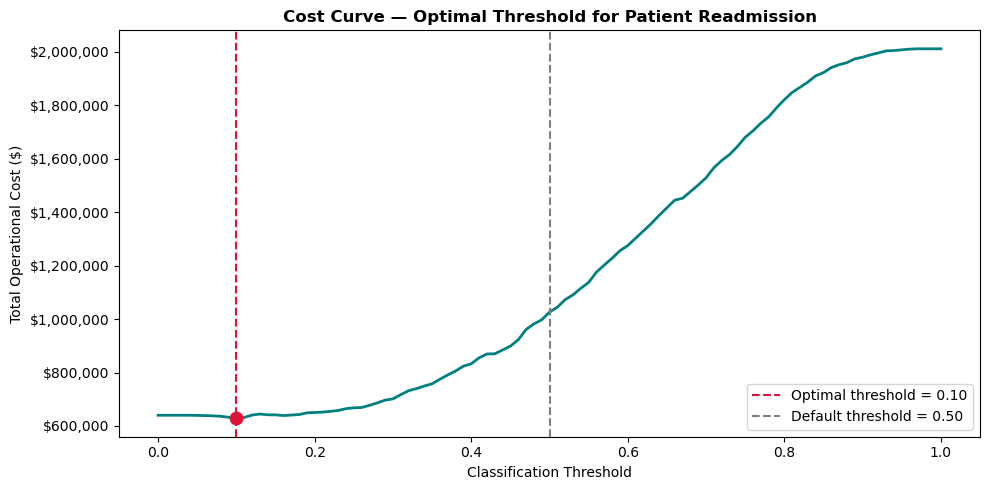

In [37]:
# 1. Generate out-of-fold predicted probabilities using Cross Validation
lr_model = models['Logistic Regression']
y_prob = cross_val_predict(
    lr_model, X_train, y_train,
    cv=cv_strategy, method='predict_proba', n_jobs=-1
)[:, 1]

# 2. Define financial constraints
cost_fp           = 200    # Cost of unnecessary intervention (false alarm)
cost_fn           = 1500   # Cost of a missed readmission
cost_intervention = 200    # Cost of early intervention per flagged patient (= cost_fp here)

# 3. Evaluate total costs across a sequence of candidate thresholds
thresholds  = np.linspace(0, 1, 101)
cost_curve  = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()

    # Correct cost formula:
    # FP = flagged but healthy → wasted intervention cost
    # FN = missed readmission → full readmission cost
    # TP = correctly flagged → intervention cost (benefit handled in Q5)
    total_cost = (fp * cost_fp) + (fn * cost_fn) + (tp * cost_intervention)
    cost_curve.append(total_cost)

# 4. Extract optimal threshold
best_idx           = np.argmin(cost_curve)
optimal_threshold  = thresholds[best_idx]
min_cost           = cost_curve[best_idx]
default_cost       = cost_curve[50]  # cost at t=0.50

print(f"Optimal Threshold:                        {optimal_threshold:.2f}")
print(f"Minimum Operational Cost:                 ${min_cost:,.2f}")
print(f"Savings vs default threshold (t=0.50):    ${default_cost - min_cost:,.2f}")

# 5. Cost curve plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, cost_curve, color='teal', linewidth=2)
ax.axvline(optimal_threshold, color='crimson', linestyle='--',
           label=f'Optimal threshold = {optimal_threshold:.2f}')
ax.axvline(0.50, color='grey', linestyle='--',
           label=f'Default threshold = 0.50')
ax.scatter(optimal_threshold, min_cost, color='crimson', zorder=5, s=80)
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Total Operational Cost ($)')
ax.set_title('Cost Curve — Optimal Threshold for Patient Readmission',
             fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## Q5 — ROI of Early Intervention

Confusion matrix at t=0.10 (test set):
  TP=333  FP=445  FN=2  TN=20

MEDPULSE PATIENT READMISSION — ROI ASSESSMENT
Test cohort: N=800 patients | 
Readmission rate: 41.9%

SCENARIO A — Status Quo (no intervention)
  All readmissions occur unimpeded
  Total cost:                $5,025,000.00

SCENARIO B — Model-Driven Early Intervention
  Flagged for intervention:     778 patients (TP=333, FP=445)
  Missed (FN):                    2 patients
  Intervention cost:         $  155,600.00
  Missed readmission cost:   $   30,000.00
  Failed intervention cost:  $3,496,500.00
  ─────────────────────────────────────────
  Total model-driven cost:   $3,682,100.00

FINANCIAL IMPACT
  Net operational savings:   $1,342,900.00
  ROI on intervention spend:       863.0%
  Savings per enrolled pt:   $    1,726.09
  Readmissions prevented:        99 patients
  (30% of 333 correctly flagged patients)

ASSUMPTIONS
  Intervention efficiency:   30% prevention rate
  Cost per readmission:      $   15,000.00
 

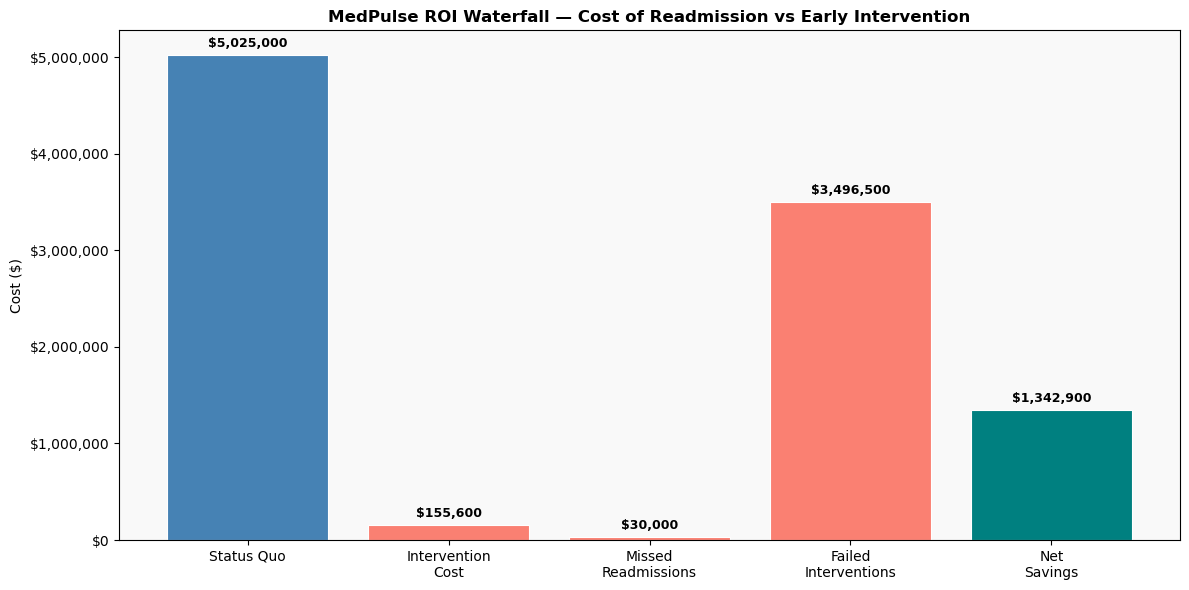

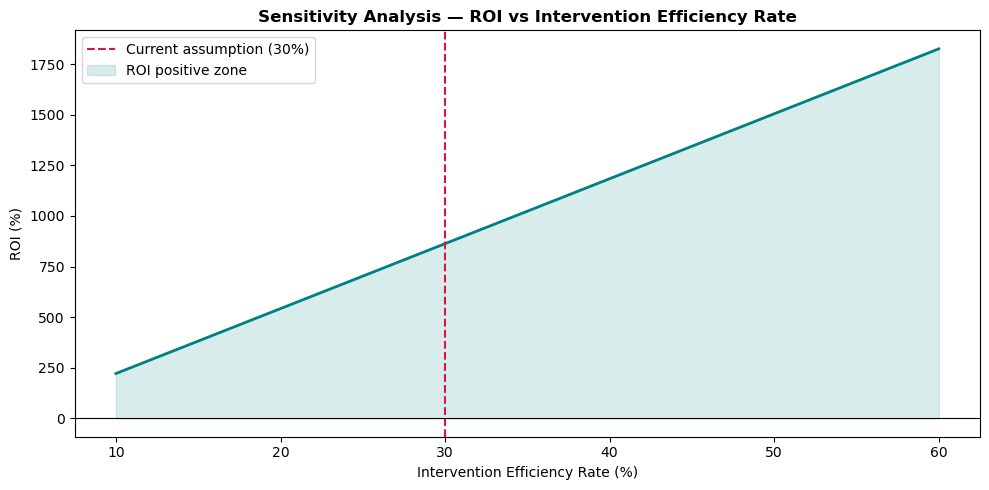

In [39]:
# 1. System parameters — all explicit assumptions upfront
cost_per_readmission  = 15000  # avg hospital cost per readmission
cost_per_intervention = 200    # early intervention program cost per patient
efficiency_rate       = 0.30   # % of flagged TPs where intervention prevents readmission

# 2. Final model fit on full X_train, evaluate on X_test
lr_final = models['Logistic Regression']
lr_final.fit(X_train, y_train)
y_proba_test = lr_final.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

print(f"Confusion matrix at t={optimal_threshold:.2f} (test set):")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

# 3. Scenario A — Status Quo (no model, no intervention)
# Every readmission happens, nothing is caught early
status_quo_cost = y_test.sum() * cost_per_readmission

# 4. Scenario B — Model-Driven Early Intervention
intervention_cost      = (tp + fp) * cost_per_intervention        # cost to flag everyone
missed_readmit_cost    = fn * cost_per_readmission                 # missed cases still readmit
failed_intervent_cost  = tp * (1 - efficiency_rate) * cost_per_readmission  # TPs where intervention failed
model_total_cost       = intervention_cost + missed_readmit_cost + failed_intervent_cost

# 5. Financial KPIs
net_savings            = status_quo_cost - model_total_cost
roi_pct                = (net_savings / intervention_cost) * 100
cost_per_enrolled      = net_savings / (tp + fp) if (tp + fp) > 0 else 0
readmissions_prevented = int(tp * efficiency_rate)

# 6. Print ROI summary
print(f"""
{'='*55}
MEDPULSE PATIENT READMISSION — ROI ASSESSMENT
Test cohort: N={len(y_test)} patients | 
Readmission rate: {y_test.mean():.1%}
{'='*55}

SCENARIO A — Status Quo (no intervention)
  All readmissions occur unimpeded
  Total cost:                ${status_quo_cost:>12,.2f}

SCENARIO B — Model-Driven Early Intervention
  Flagged for intervention:  {tp + fp:>6} patients (TP={tp}, FP={fp})
  Missed (FN):               {fn:>6} patients
  Intervention cost:         ${intervention_cost:>12,.2f}
  Missed readmission cost:   ${missed_readmit_cost:>12,.2f}
  Failed intervention cost:  ${failed_intervent_cost:>12,.2f}
  ─────────────────────────────────────────
  Total model-driven cost:   ${model_total_cost:>12,.2f}

FINANCIAL IMPACT
  Net operational savings:   ${net_savings:>12,.2f}
  ROI on intervention spend: {roi_pct:>11.1f}%
  Savings per enrolled pt:   ${cost_per_enrolled:>12,.2f}
  Readmissions prevented:    {readmissions_prevented:>6} patients
  ({efficiency_rate:.0%} of {tp} correctly flagged patients)

ASSUMPTIONS
  Intervention efficiency:   {efficiency_rate:.0%} prevention rate
  Cost per readmission:      ${cost_per_readmission:>12,.2f}
  Cost per intervention:     ${cost_per_intervention:>12,.2f}
  Threshold:                 {optimal_threshold:.2f} (cost-optimised in Q4)
{'='*55}
""")

# 7. Waterfall chart — cost breakdown
categories = [
    'Status Quo',
    'Intervention\nCost',
    'Missed\nReadmissions',
    'Failed\nInterventions',
    'Net\nSavings'
]
values = [
    status_quo_cost,
    -intervention_cost,
    -missed_readmit_cost,
    -failed_intervent_cost,
    net_savings
]
colors = ['steelblue', 'salmon', 'salmon', 'salmon', 'teal']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(categories, [abs(v) for v in values], color=colors, edgecolor='white', linewidth=0.8)

# Annotate bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + status_quo_cost * 0.01,
            f'${abs(val):,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('MedPulse ROI Waterfall — Cost of Readmission vs Early Intervention',
             fontweight='bold')
ax.set_ylabel('Cost ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

# 8. Sensitivity analysis — ROI across efficiency rates
efficiency_range = np.linspace(0.10, 0.60, 50)
roi_range = []

for eff in efficiency_range:
    failed_cost = tp * (1 - eff) * cost_per_readmission
    total_cost  = intervention_cost + missed_readmit_cost + failed_cost
    savings     = status_quo_cost - total_cost
    roi_range.append((savings / intervention_cost) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(efficiency_range * 100, roi_range, color='teal', linewidth=2)
ax.axvline(efficiency_rate * 100, color='crimson', linestyle='--',
           label=f'Current assumption ({efficiency_rate:.0%})')
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.fill_between(efficiency_range * 100, roi_range,
                where=[r > 0 for r in roi_range],
                alpha=0.15, color='teal', label='ROI positive zone')
ax.set_xlabel('Intervention Efficiency Rate (%)')
ax.set_ylabel('ROI (%)')
ax.set_title('Sensitivity Analysis — ROI vs Intervention Efficiency Rate',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()